# 03_问题三结果分析与可视化

本 notebook 只读取已完成的模拟结果 CSV（位于 results/outputs/），不再运行新的蒙特卡洛模拟。
内容包括：
- 粗扫 + 精细扫描的 p(f) 曲线与局部放大
- 在最终候选 f=0.00011 (0.011%) 的样本可视化（2D/3D）
- 边界截断（周期性平移）示意图（2D）
- 结果表格与结论总结

请先确认 results/outputs/ 下存在：
- coarse_scan_p90.csv
- fine_scan_p90.csv
- final_p90_answer.csv

#  Code (imports、全局配置、路径、字体)

In [1]:
# Cell 2: imports and configuration
import os
import sys
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 获取项目根目录（假设 notebook 在 notebooks/ 下运行）
repo_root = Path(os.getcwd()).parent  # 从 notebooks/ 回到项目根目录

# plotting: Chinese font
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# output dirs and files（基于项目根目录）
OUT_DIR = repo_root / 'results' / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_DIR = repo_root / 'results' / 'outputs'
coarse_csv_path = CSV_DIR / 'coarse_scan_p90.csv'
fine_csv_path = CSV_DIR / 'fine_scan_p90.csv'
final_csv_path = CSV_DIR / 'final_p90_answer.csv'

print("Project root:", repo_root)
print("Figures will be saved to:", OUT_DIR)
print("Expecting CSVs at:", CSV_DIR)

Project root: f:\数模专用\2026_HuaShuCup_Problem_A
Figures will be saved to: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures
Expecting CSVs at: f:\数模专用\2026_HuaShuCup_Problem_A\results\outputs


#  Code (helpers: compute N, wilson interval, safe read)

In [2]:
# Cell 3: helper functions
def wilson_interval(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0
    phat = k / n
    denom = 1 + (z**2) / n
    centre = phat + (z**2) / (2 * n)
    adj = z * math.sqrt((phat*(1-phat) + (z**2) / (4*n)) / n)
    low = (centre - adj) / denom
    high = (centre + adj) / denom
    return max(0.0, low), min(1.0, high)

def compute_N_from_f(f, Lbox, r, h):
    V_box = Lbox**3
    V_cyl = math.pi * (r**2) * h
    return max(0, int(round((f * V_box) / V_cyl)))

# read CSVs with graceful fallback
def load_csv_safe(path):
    if not path.exists():
        print("Warning: CSV not found:", path)
        return None
    try:
        df = pd.read_csv(path)
        return df
    except Exception as e:
        print("Failed to read", path, ":", e)
        return None

# Code (load data; merge coarse+fine)

In [4]:
# Cell 4: load coarse and fine CSVs
import os
# 获取项目根目录（假设 notebook 在 notebooks/ 下）
repo_root = os.path.dirname(os.getcwd())  # 从 notebooks/ 回到项目根目录

# 然后用 repo_root 拼接路径
from pathlib import Path

coarse_csv_path = Path(os.path.join(repo_root, 'results/outputs/coarse_scan_p90.csv'))
fine_csv_path = Path(os.path.join(repo_root, 'results/outputs/fine_scan_p90.csv'))
final_csv_path = Path(os.path.join(repo_root, 'results/outputs/final_p90_answer.csv'))

#coarse_csv_path = os.path.join(repo_root, 'results/outputs/coarse_scan_p90.csv')
#fine_csv_path = os.path.join(repo_root, 'results/outputs/fine_scan_p90.csv')
#final_csv_path = os.path.join(repo_root, 'results/outputs/final_p90_answer.csv')

df_coarse = load_csv_safe(coarse_csv_path)
df_fine = load_csv_safe(fine_csv_path)
df_final = load_csv_safe(final_csv_path)

if df_coarse is None and df_fine is None:
    raise FileNotFoundError("Neither coarse nor fine CSV found under results/outputs/. Please check path.")

# Normalize columns and ensure f in fraction (0-1)
def ensure_f_fraction(df):
    if df is None:
        return None
    df = df.copy()
    if 'f' not in df.columns:
        raise KeyError("CSV missing 'f' column")
    # If f looks like percent (>1), convert
    if df['f'].max() > 1.5:
        df['f'] = df['f'] / 100.0
    # ensure required columns exist
    if 'p_hat' not in df.columns:
        raise KeyError("CSV missing 'p_hat' column")
    if 'ci_low' not in df.columns or 'ci_high' not in df.columns:
        # try to compute from successes/trials if available
        if {'successes','trials'}.issubset(df.columns):
            lows = []
            highs = []
            for k,n in zip(df['successes'].fillna(0).astype(int), df['trials'].fillna(0).astype(int)):
                lo,hi = wilson_interval(int(k), int(n))
                lows.append(lo); highs.append(hi)
            df['ci_low'] = np.array(lows)
            df['ci_high'] = np.array(highs)
        else:
            # fallback small symmetric interval
            df['ci_low'] = np.clip(df['p_hat'] - 0.02, 0.0, 1.0)
            df['ci_high'] = np.clip(df['p_hat'] + 0.02, 0.0, 1.0)
    return df

df_coarse = ensure_f_fraction(df_coarse)
df_fine = ensure_f_fraction(df_fine)

# Merge: combine and sort by f; mark source
parts = []
if df_coarse is not None:
    tmp = df_coarse.copy(); tmp['source'] = 'coarse'; parts.append(tmp)
if df_fine is not None:
    tmp = df_fine.copy(); tmp['source'] = 'fine'; parts.append(tmp)
df_all = pd.concat(parts, ignore_index=True).sort_values('f').reset_index(drop=True)
print("Total points loaded:", len(df_all))

Total points loaded: 57


# Code (Main curve: full p(f) plot — coarse hollow circles, fine filled)

Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\p_vs_f_problem3.png


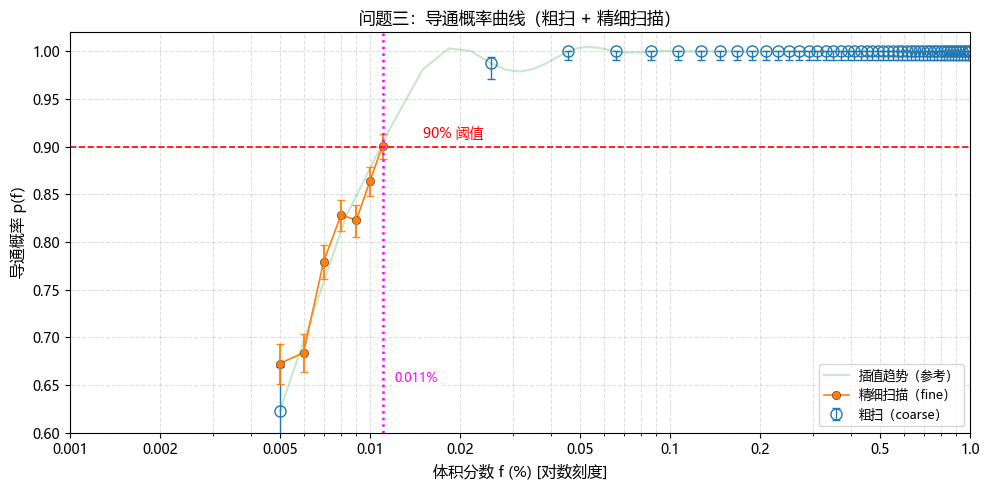

In [5]:
# 图1：主图（优化版：对数横轴 + Y轴范围调整）
final_f_fraction = 0.00011
final_f_pct = final_f_fraction * 100.0

df_coarse_plot = df_coarse if (df_coarse is not None) else pd.DataFrame(columns=['f','p_hat','ci_low','ci_high'])
df_fine_plot = df_fine if (df_fine is not None) else pd.DataFrame(columns=['f','p_hat','ci_low','ci_high'])

if df_coarse_plot.empty and 'df_all' in globals():
    df_coarse_plot = df_all[df_all['source']=='coarse'] if 'source' in df_all.columns else pd.DataFrame()

fig, ax = plt.subplots(figsize=(10, 5))

# 合并数据用于插值
df_comb = pd.concat([df_coarse_plot, df_fine_plot], ignore_index=True).drop_duplicates(subset=['f']).sort_values('f')

if len(df_comb) >= 4:
    xs = df_comb['f'].values
    ys = df_comb['p_hat'].values
    try:
        from scipy.interpolate import make_interp_spline
        x_lin = np.linspace(xs.min(), xs.max(), 300)
        spline = make_interp_spline(xs, ys, k=3)
        y_smooth = spline(x_lin)
        ax.plot(x_lin * 100.0, y_smooth, color='C2', alpha=0.25, linewidth=1.5, label='插值趋势（参考）')
    except Exception:
        pass

# 粗扫：空心圆
if not df_coarse_plot.empty:
    x_c = df_coarse_plot['f'].values * 100.0
    y_c = df_coarse_plot['p_hat'].values
    yerr_low = y_c - df_coarse_plot['ci_low'].values
    yerr_high = df_coarse_plot['ci_high'].values - y_c
    ax.errorbar(x_c, y_c, yerr=[yerr_low, yerr_high],
                fmt='o', markersize=8, markerfacecolor='none',
                markeredgecolor='C0', ecolor='C0', capsize=3, linewidth=1, label='粗扫（coarse）')

# 精细扫描：实心圆 + 连线
if not df_fine_plot.empty:
    x_f = df_fine_plot['f'].values * 100.0
    y_f = df_fine_plot['p_hat'].values
    yerr_low_f = y_f - df_fine_plot['ci_low'].values
    yerr_high_f = df_fine_plot['ci_high'].values - y_f
    ax.plot(x_f, y_f, '-o', color='C1', linewidth=1.2, markersize=6, markeredgecolor='k', markeredgewidth=0.3, label='精细扫描（fine）')
    ax.errorbar(x_f, y_f, yerr=[yerr_low_f, yerr_high_f], fmt='none', ecolor='C1', alpha=0.9, capsize=3)

# 阈值线
ax.axhline(0.9, color='red', linestyle='--', linewidth=1.2)

# ===== 对数横轴 =====
ax.set_xscale('log')
ax.set_xlim(0.001, 1.0)
ax.set_xticks([0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0])
ax.set_xticklabels(['0.001', '0.002', '0.005', '0.01', '0.02', '0.05', '0.1', '0.2', '0.5', '1.0'])

# ===== 关键修改：Y轴范围调整 =====
ax.set_ylim(0.6, 1.02)  # 从 0.6 开始，留一点余量到 1.02

# 标注
ax.text(0.015, 0.905, '90% 阈值', color='red', ha='left', va='bottom', fontsize=10)
ax.axvline(final_f_pct, color='magenta', linestyle=':', linewidth=1.8)
ax.text(final_f_pct * 1.1, 0.65, f"{final_f_pct:.3f}%", color='magenta', va='bottom', ha='left', fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

ax.set_xlabel('体积分数 f (%) [对数刻度]', fontsize=11)
ax.set_ylabel('导通概率 p(f)', fontsize=11)
ax.set_title('问题三：导通概率曲线（粗扫 + 精细扫描）', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4, which='both')
ax.legend(loc='lower right', fontsize=9)

fig.tight_layout()
out_path = OUT_DIR / 'p_vs_f_problem3.png'
fig.savefig(out_path, dpi=300)
print("Saved:", out_path)
plt.show()

# Cell 6 — Code (Local zoom: fine data between 0.005%~0.015%, annotate N next to each point)

Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\p_vs_f_fine_problem3.png


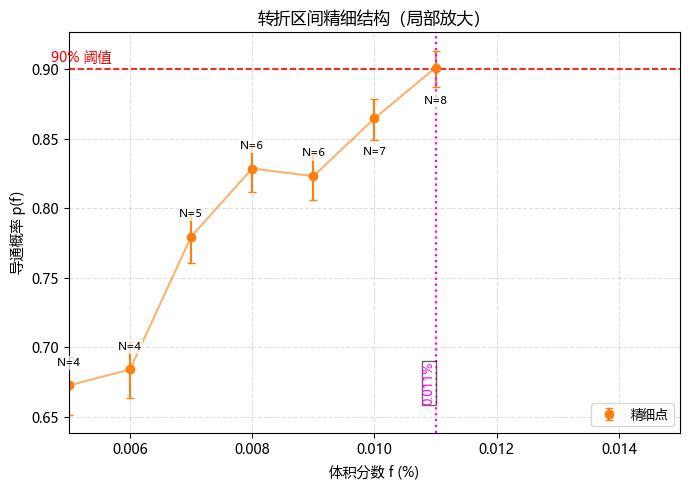

In [6]:
# 图2：局部放大（替换原 Cell 6）
# define zoom range in percent (ensure it includes data range)
zoom_min_pct = 0.005
# set zoom max to max of requested or actual fine data max (converted to percent)
fine_max_pct = (df_fine['f'].max() * 100.0) if (df_fine is not None and not df_fine.empty) else 0.015
zoom_max_pct = max(0.015, fine_max_pct)  # ensure at least 0.015%

if df_fine is None or df_fine.empty:
    print("No fine scan data available for local zoom plot.")
else:
    df_zoom = df_fine[(df_fine['f']*100.0 >= zoom_min_pct) & (df_fine['f']*100.0 <= zoom_max_pct)].copy()
    if df_zoom.empty:
        print("精细扫描在指定范围内无数据。将显示全部精细扫描数据。")
        df_zoom = df_fine.copy()

    # compute N if missing
    if 'N' not in df_zoom.columns:
        L_box = 10000.0; r_cyl = 30.0; h_cyl = 5000.0
        df_zoom['N'] = df_zoom['f'].apply(lambda f: compute_N_from_f(f, L_box, r_cyl, h_cyl))

    fig, ax = plt.subplots(figsize=(7,5))
    x = df_zoom['f'].values * 100.0
    y = df_zoom['p_hat'].values
    ylow = df_zoom['ci_low'].values
    yhigh = df_zoom['ci_high'].values

    # plot errorbars and points
    ax.errorbar(x, y, yerr=[y - ylow, yhigh - y], fmt='o', color='C1', ecolor='C1', capsize=3, markersize=6, label='精细点')
    ax.plot(x, y, '-', color='C1', alpha=0.6)

    # annotate N for each point with small offset; alternate offset to reduce overlap
    for i, (xi, yi, Ni) in enumerate(zip(x, y, df_zoom['N'].values)):
        # dynamic offset: if yi > 0.8 place below, else place above
        y_offset = 0.012 if yi < 0.85 else -0.02
        ax.text(xi, yi + y_offset, f"N={int(Ni)}", ha='center', va='bottom' if y_offset>0 else 'top', fontsize=8,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7))

    # 90% line and final answer mark
    ax.axhline(0.9, color='red', linestyle='--', linewidth=1.2)
    ax.text(ax.get_xlim()[0], 0.902, '90% 阈值', color='red', va='bottom')

    ax.axvline(final_f_pct, color='magenta', linestyle=':', linewidth=1.6)
    ax.text(final_f_pct, ax.get_ylim()[0] + 0.02, f"{final_f_pct:.3f}%", color='magenta', rotation=90, va='bottom', ha='right', fontsize=9, bbox=dict(fc='white', alpha=0.6, pad=0.2))

    ax.set_xlim(zoom_min_pct, zoom_max_pct)
    ax.set_xlabel('体积分数 f (%)')
    ax.set_ylabel('导通概率 p(f)')
    ax.set_title('转折区间精细结构（局部放大）')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower right', fontsize=9)

    out_zoom = OUT_DIR / 'p_vs_f_fine_problem3.png'
    fig.tight_layout()
    fig.savefig(out_zoom, dpi=300)
    print("Saved:", out_zoom)
    plt.show()

# Cell 7 — Code (准备 for 2D/3D simulation visualization — import src and helper functions)

In [7]:
# Cell 7: load src modules and helper functions for visualization (use fixed seed)
import os
import sys
import numpy as np

# 获取项目根目录（notebook 在 notebooks/ 下运行）
repo_root = os.path.dirname(os.getcwd())  # 从 notebooks/ 回到项目根目录
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print("Project root added to sys.path:", repo_root)

from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity, UnionFind  # if available

# sampling function (same sampling used in simulation scripts)
def sample_random_cylinders(N, Lbox, rad, length, seed=None):
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-Lbox/2, Lbox/2, size=(N, 3))
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    dirs = dirs / norms
    half = length / 2.0
    cyls = []
    for i in range(N):
        c = centers[i]
        d = dirs[i]
        p0 = c - d * half
        p1 = c + d * half
        cyls.append(Cylinder(p0, p1, rad, id=i))
    return cyls

# function to find conducting cluster indices (tries union-find PLANE nodes, fallback to geometric test)
def get_conducting_cluster_indices(segments, Lbox, thr):
    # Try build_connectivity result
    connected, uf = build_connectivity(segments, Lbox, thr)
    # We expect the union-find to have special plane nodes; try to find them
    try:
        left_root = uf.find(("PLANE", "LEFT"))
        right_root = uf.find(("PLANE", "RIGHT"))
        if left_root == right_root:
            target_root = left_root
            idxs = [i for i in range(len(segments)) if uf.find(i) == target_root]
            return True, idxs, uf
    except Exception:
        pass
    # Fallback: detect segments that touch left and right (geometrically) and see intersection of components
    # build list of left-touching and right-touching segments
    left_idxs = []
    right_idxs = []
    half = Lbox / 2.0
    for i, s in enumerate(segments):
        # check if segment is within threshold of left plane x = -half
        # use min distance between segment and plane by projecting endpoints
        xs = np.array([s.p0[0], s.p1[0]])
        if xs.min() - (-half) <= thr + s.r:
            left_idxs.append(i)
        if half - xs.max() <= thr + s.r:
            right_idxs.append(i)
    # use uf if available to map components
    try:
        left_roots = set(uf.find(i) for i in left_idxs)
        right_roots = set(uf.find(i) for i in right_idxs)
        inter = left_roots & right_roots
        if inter:
            root = next(iter(inter))
            idxs = [i for i in range(len(segments)) if uf.find(i) == root]
            return True, idxs, uf
    except Exception:
        pass
    return False, [], uf if 'uf' in locals() else None

Project root added to sys.path: f:\数模专用\2026_HuaShuCup_Problem_A


# Cell 8 — Code (2D projection visualization at f=0.00011)

Sampling for visualization: f = 0.00011 N = 8 seed = 20260812
Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_2d_problem3.png


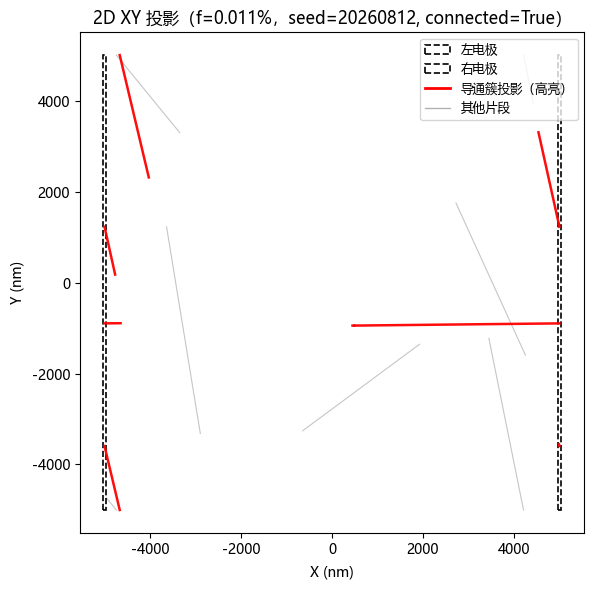

In [8]:
# 图3：2D 投影（替换原 Cell 8） — 用线段投影展示连通路径
L_box = 10000.0; r_cyl = 30.0; h_cyl = 5000.0
final_f = 0.00011
seed_vis = 20260812
N_final = compute_N_from_f(final_f, L_box, r_cyl, h_cyl)
print("Sampling for visualization: f =", final_f, "N =", N_final, "seed =", seed_vis)

cyls = sample_random_cylinders(N_final, L_box, r_cyl, h_cyl, seed=seed_vis)
segments = []
for c in cyls:
    segments.extend(split_cylinder_by_box(c, L_box))

connected, cluster_idxs, uf = get_conducting_cluster_indices(segments, L_box, thr=1.8)

# Plot as projected line segments on XY plane
fig, ax = plt.subplots(figsize=(7,6))
for i, s in enumerate(segments):
    x0,y0 = s.p0[0], s.p0[1]
    x1,y1 = s.p1[0], s.p1[1]
    if i in cluster_idxs:
        ax.plot([x0,x1],[y0,y1], color='red', linewidth=1.8, alpha=0.95, zorder=3)
    else:
        ax.plot([x0,x1],[y0,y1], color='gray', linewidth=0.8, alpha=0.45, zorder=1)

# electrodes: shaded rectangles at x = ±half (thin bands)
half = L_box/2.0
electrode_width = 80.0  # visualize electrode thickness
ax.add_patch(plt.Rectangle((-half-electrode_width/2, -L_box/2), electrode_width, L_box, facecolor='none', edgecolor='k', linestyle='--', linewidth=1.2, label='左电极'))
ax.add_patch(plt.Rectangle((half-electrode_width/2, -L_box/2), electrode_width, L_box, facecolor='none', edgecolor='k', linestyle='--', linewidth=1.2, label='右电极'))

# highlight (legend)
ax.plot([], [], color='red', linewidth=2, label='导通簇投影（高亮）')
ax.plot([], [], color='gray', linewidth=1, alpha=0.6, label='其他片段')

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_title(f'2D XY 投影（f={final_f*100:.3f}%，seed={seed_vis}, connected={connected}）')
ax.set_aspect('equal', 'box')
ax.grid(False)
ax.legend(loc='upper right', fontsize=9)
out2d = OUT_DIR / 'cluster_2d_problem3.png'
fig.tight_layout()
fig.savefig(out2d, dpi=300)
print("Saved:", out2d)
plt.show()

Sampling for visualization: f = 0.00011 N = 8 seed = 20260812
Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_2d_problem3.png


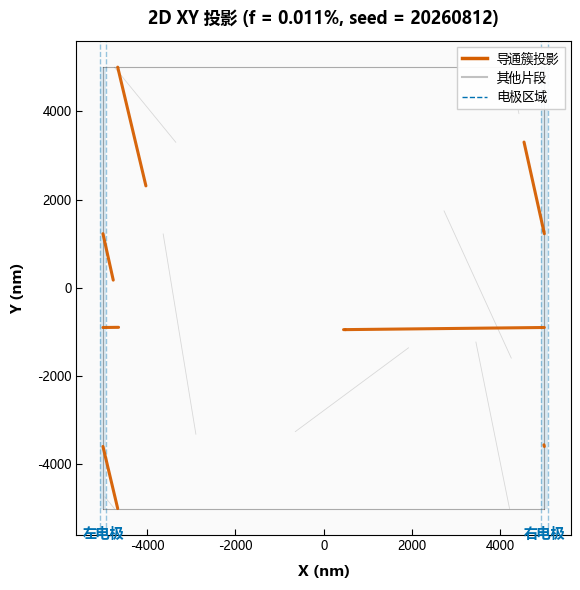

In [9]:
# === 图：2D XY 投影（工科论文风格） ===
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

L_box = 10000.0
r_cyl = 30.0
h_cyl = 5000.0
final_f = 0.00011
seed_vis = 20260812
N_final = compute_N_from_f(final_f, L_box, r_cyl, h_cyl)
print("Sampling for visualization: f =", final_f, "N =", N_final, "seed =", seed_vis)

cyls = sample_random_cylinders(N_final, L_box, r_cyl, h_cyl, seed=seed_vis)
segments = []
for c in cyls:
    segments.extend(split_cylinder_by_box(c, L_box))

connected, cluster_idxs, uf = get_conducting_cluster_indices(segments, L_box, thr=1.8)

# 颜色定义（Nature 风格，色盲友好）
COLOR_CONDUCTING = '#D55E00'   # 朱红（导通簇）
COLOR_OTHER = '#999999'       # 中灰（其他片段）
COLOR_ELECTRODE = '#0072B2'   # 深蓝（电极）
COLOR_BOX = '#333333'         # 深灰（边框）

# 创建图形（尺寸适合论文双栏）
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#FAFAFA')   # 极浅灰背景，增加层次感

# --- 1. 绘制所有片段（先画非导通，后画导通，确保导通在上层） ---
# 非导通片段（浅灰色，细线）
for i, s in enumerate(segments):
    if i in cluster_idxs:
        continue
    x0, y0 = s.p0[0], s.p0[1]
    x1, y1 = s.p1[0], s.p1[1]
    ax.plot([x0, x1], [y0, y1], 
            color=COLOR_OTHER, linewidth=0.6, alpha=0.35, zorder=1, solid_capstyle='round')

# 导通片段（朱红色，加粗）
for i, s in enumerate(segments):
    if i not in cluster_idxs:
        continue
    x0, y0 = s.p0[0], s.p0[1]
    x1, y1 = s.p1[0], s.p1[1]
    ax.plot([x0, x1], [y0, y1], 
            color=COLOR_CONDUCTING, linewidth=2.2, alpha=0.95, zorder=3, solid_capstyle='round')

# --- 2. 电极区域（半透明带状，比虚线更直观） ---
half = L_box / 2.0
electrode_width = 150.0  # 电极带宽度

# 左电极（半透明蓝色带）
left_band = Rectangle(
    (-half - electrode_width/2, -half), 
    electrode_width, L_box,
    facecolor=COLOR_ELECTRODE, edgecolor='none', alpha=0.12, zorder=0
)
ax.add_patch(left_band)
# 左电极边界线
ax.axvline(-half - electrode_width/2, color=COLOR_ELECTRODE, linewidth=1.0, alpha=0.4, linestyle='--')
ax.axvline(-half + electrode_width/2, color=COLOR_ELECTRODE, linewidth=1.0, alpha=0.4, linestyle='--')
# 左电极标签
ax.text(-half, -half - 400, '左电极', fontsize=10, fontweight='bold', 
        color=COLOR_ELECTRODE, ha='center', va='top')

# 右电极（半透明蓝色带）
right_band = Rectangle(
    (half - electrode_width/2, -half), 
    electrode_width, L_box,
    facecolor=COLOR_ELECTRODE, edgecolor='none', alpha=0.12, zorder=0
)
ax.add_patch(right_band)
ax.axvline(half - electrode_width/2, color=COLOR_ELECTRODE, linewidth=1.0, alpha=0.4, linestyle='--')
ax.axvline(half + electrode_width/2, color=COLOR_ELECTRODE, linewidth=1.0, alpha=0.4, linestyle='--')
ax.text(half, -half - 400, '右电极', fontsize=10, fontweight='bold', 
        color=COLOR_ELECTRODE, ha='center', va='top')

# --- 3. 盒子边框（精细线框） ---
ax.plot([-half, half], [-half, -half], color=COLOR_BOX, linewidth=0.8, alpha=0.4)
ax.plot([-half, half], [half, half], color=COLOR_BOX, linewidth=0.8, alpha=0.4)
ax.plot([-half, -half], [-half, half], color=COLOR_BOX, linewidth=0.8, alpha=0.4)
ax.plot([half, half], [-half, half], color=COLOR_BOX, linewidth=0.8, alpha=0.4)

# --- 4. 坐标轴与刻度（精简） ---
ax.set_xlabel('X (nm)', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel('Y (nm)', fontsize=11, fontweight='bold', labelpad=8)

# 设置刻度
ax.set_xticks([-4000, -2000, 0, 2000, 4000])
ax.set_yticks([-4000, -2000, 0, 2000, 4000])
ax.tick_params(axis='both', labelsize=9, direction='in', length=4, width=0.8)

# 设置坐标轴范围（留边距）
margin = 600
ax.set_xlim(-half - margin, half + margin)
ax.set_ylim(-half - margin, half + margin)

# 等比例
ax.set_aspect('equal', adjustable='box')

# --- 5. 图例（精简，放在右上角空白区） ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=COLOR_CONDUCTING, linewidth=2.5, label='导通簇投影'),
    Line2D([0], [0], color=COLOR_OTHER, linewidth=1.5, alpha=0.6, label='其他片段'),
    Line2D([0], [0], color=COLOR_ELECTRODE, linewidth=1.0, linestyle='--', label='电极区域'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, 
          frameon=True, framealpha=0.92, edgecolor='#CCCCCC', fancybox=False)

# --- 6. 标题（简洁，放在图上方） ---
ax.set_title(f'2D XY 投影 (f = {final_f*100:.3f}%, seed = {seed_vis})', 
             fontsize=12, fontweight='bold', pad=12, loc='center')

# --- 7. 保存（高分辨率） ---
out2d = OUT_DIR / 'cluster_2d_problem3.png'
plt.tight_layout()
plt.savefig(out2d, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out2d}")
plt.show()

No path found by BFS. Falling back to ordering by X coordinate of centers.
Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_2d_problem3.png


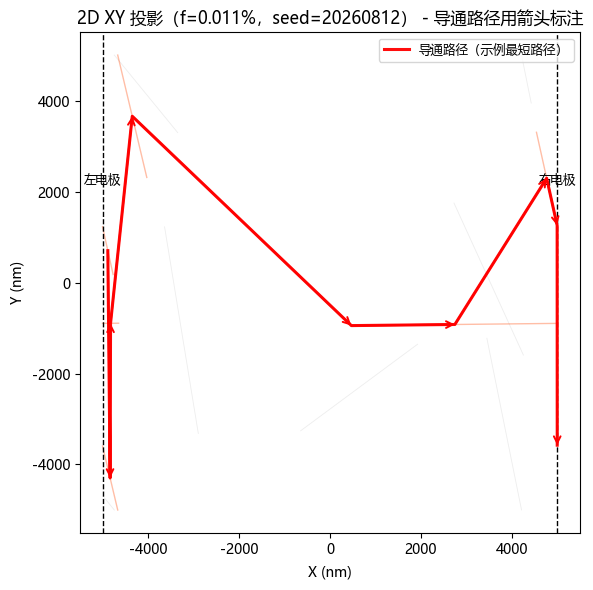

In [10]:
# === 2D 投影（带路径箭头） - 替换原 Cell 8 内容 ===
# 依赖：segments, cluster_idxs, L_box, r_cyl, h_cyl, seed_vis 已在 notebook 中定义
import numpy as np
from collections import deque

# 参数（若 notebook 中已有相同变量可忽略）
thr = 1.8        # 连接阈值（nm）
margin = 1.0     # 邻接判断的容差

# compute centers for segments
centers = np.array([((s.p0 + s.p1) / 2.0) for s in segments])
# indices in cluster
cluster_idx_list = [i for i in cluster_idxs if 0 <= i < len(segments)]
if len(cluster_idx_list) == 0:
    print("No conducting cluster segments found; drawing fallback projection.")
# Build adjacency among cluster nodes (pairwise distance on centers)
def build_adj(cluster_idxs, centers, r_seg, thr, margin=0.0):
    # adjacency if distance between centers <= 2*r + thr + margin
    maxd = 2.0 * r_seg + thr + margin
    adj = {i: set() for i in cluster_idxs}
    for i_idx, i in enumerate(cluster_idxs):
        for j_idx in range(i_idx+1, len(cluster_idxs)):
            j = cluster_idxs[j_idx]
            d = np.linalg.norm(centers[i] - centers[j])
            if d <= maxd:
                adj[i].add(j); adj[j].add(i)
    return adj

# find nodes that touch left and right electrodes
half = L_box / 2.0
left_nodes = [i for i in cluster_idx_list if min(segments[i].p0[0], segments[i].p1[0]) <= -half + thr + 1e-6]
right_nodes = [i for i in cluster_idx_list if max(segments[i].p0[0], segments[i].p1[0]) >= half - thr - 1e-6]

adj = build_adj(cluster_idx_list, centers, r_cyl, thr, margin=margin)

# BFS shortest path from any left_node to any right_node
def bfs_shortest_path(adj, starts, goals):
    if len(starts)==0 or len(goals)==0:
        return None
    visited = set()
    q = deque()
    # push all starts
    for s in starts:
        q.append((s, [s]))
        visited.add(s)
    goal_set = set(goals)
    while q:
        node, path = q.popleft()
        if node in goal_set:
            return path
        for nb in adj.get(node, ()):
            if nb not in visited:
                visited.add(nb)
                q.append((nb, path + [nb]))
    return None

path = bfs_shortest_path(adj, left_nodes, right_nodes)
# Fallback: if no path found, try simple ordering by X coordinate
if path is None:
    print("No path found by BFS. Falling back to ordering by X coordinate of centers.")
    # take cluster centers sorted by x
    path = sorted(cluster_idx_list, key=lambda i: centers[i,0])

# Plot XY projection with line segments and arrows along path
fig, ax = plt.subplots(figsize=(7,6))
# draw all segments as light gray lines
for i, s in enumerate(segments):
    x0, y0 = s.p0[0], s.p0[1]
    x1, y1 = s.p1[0], s.p1[1]
    if i in cluster_idx_list:
        # draw faint red for cluster (base)
        ax.plot([x0, x1], [y0, y1], color='orangered', linewidth=1.0, alpha=0.35, zorder=1)
    else:
        ax.plot([x0, x1], [y0, y1], color='lightgray', linewidth=0.6, alpha=0.4, zorder=0)

# draw path segments thicker and draw arrows between consecutive centers
if path:
    # draw thick line along path centers projection
    pts = np.array([centers[i][:2] for i in path])  # (x,y)
    ax.plot(pts[:,0], pts[:,1], color='red', linewidth=2.2, alpha=0.95, zorder=4, label='导通路径（示例最短路径）')
    # draw arrowheads between consecutive center points
    for a,b in zip(pts[:-1], pts[1:]):
        # arrow length scaling
        dx = b[0] - a[0]; dy = b[1] - a[1]
        if np.hypot(dx, dy) < 1e-6:
            continue
        # place arrow at 40% along segment for visibility
        ax.annotate('', xy=(b[0], b[1]), xytext=(a[0], a[1]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.4, shrinkA=0, shrinkB=0),
                    size=12, zorder=5)

# electrodes visual
ax.axvline(-half, color='k', linestyle='--', linewidth=1.0)
ax.axvline( half, color='k', linestyle='--', linewidth=1.0)
ax.text(-half, 0.45*L_box/2.0, '左电极', ha='center', va='center', fontsize=9)
ax.text( half, 0.45*L_box/2.0, '右电极', ha='center', va='center', fontsize=9)

# legend and layout
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_title(f'2D XY 投影（f={final_f*100:.3f}%，seed={seed_vis}） - 导通路径用箭头标注')
ax.set_aspect('equal', 'box')
ax.grid(False)
ax.legend(loc='upper right', fontsize=9)
out2d = OUT_DIR / 'cluster_2d_problem3.png'
fig.tight_layout()
fig.savefig(out2d, dpi=300)
print("Saved:", out2d)
plt.show()

Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_2d_problem3.png


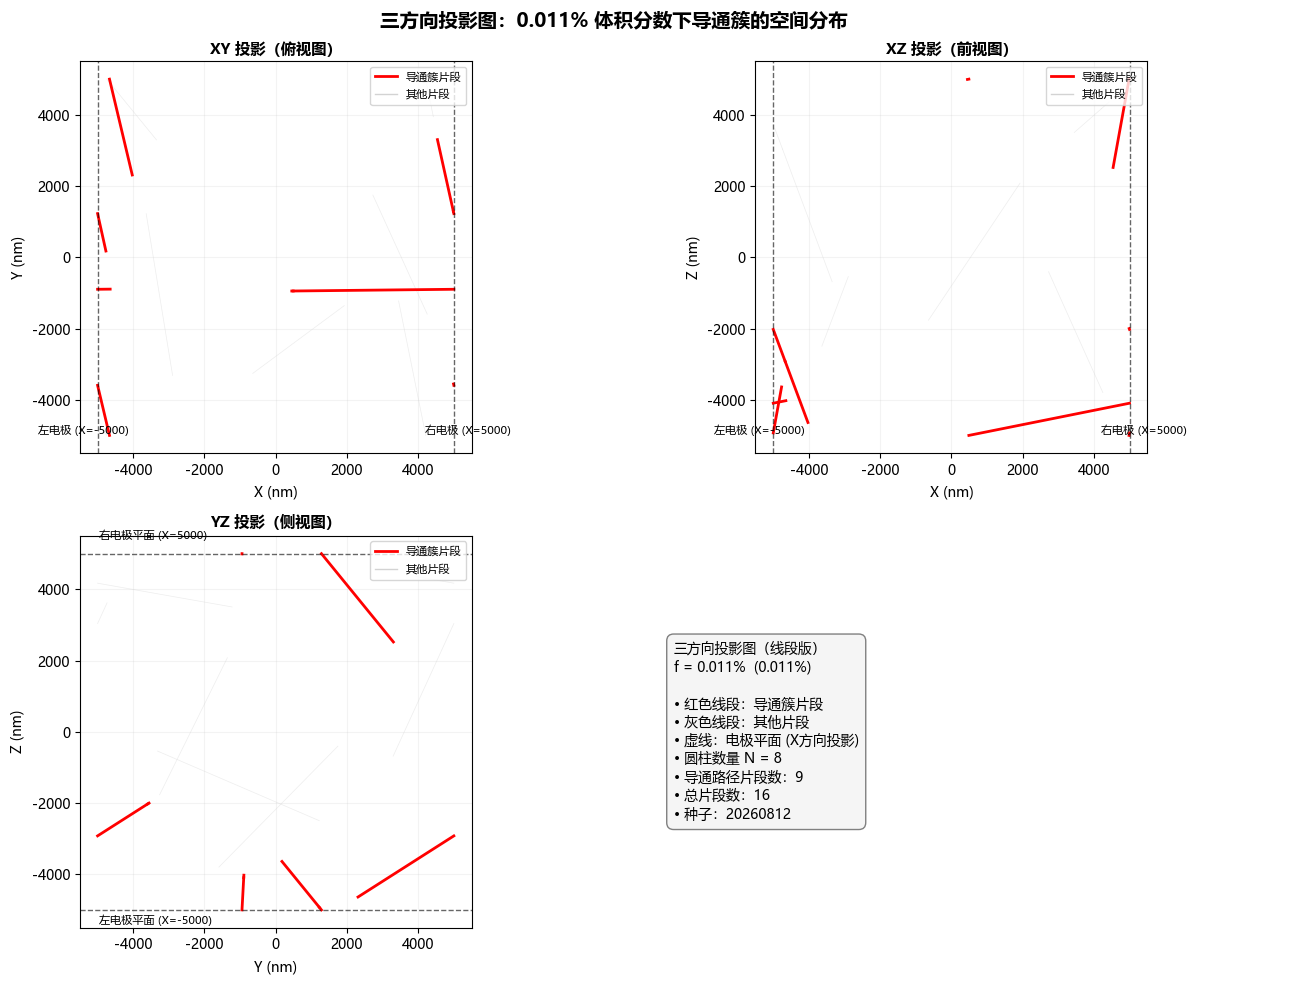

In [11]:
# 图3：三方向投影图（线段版：XY、XZ、YZ 并列）
from matplotlib.lines import Line2D

final_f = 0.00011
seed_vis = 20260812
N_final = compute_N_from_f(final_f, L_box, r_cyl, h_cyl)

# 固定种子生成样本
cyls = sample_random_cylinders(N_final, L_box, r_cyl, h_cyl, seed=seed_vis)
segments = []
for c in cyls:
    segments.extend(split_cylinder_by_box(c, L_box))

connected, cluster_idxs, uf = get_conducting_cluster_indices(segments, L_box, thr=1.8)

# 判断哪些片段属于导通簇
is_conducting = np.zeros(len(segments), dtype=bool)
for idx in cluster_idxs:
    if 0 <= idx < len(is_conducting):
        is_conducting[idx] = True

# 创建 2x2 子图布局
fig = plt.figure(figsize=(14, 10))

# 图例句柄（统一使用）
legend_elements = [
    Line2D([0], [0], color='red', linewidth=2, label='导通簇片段'),
    Line2D([0], [0], color='lightgray', linewidth=1, label='其他片段')
]

# 辅助函数：绘制一个方向的投影（线段版）
def plot_projection(ax, idx1, idx2, xlabel, ylabel, title, show_electrodes=True):
    # 绘制非导通片段（灰色细线）
    for i, s in enumerate(segments):
        if is_conducting[i]:
            continue
        p1 = s.p0
        p2 = s.p1
        ax.plot([p1[idx1], p2[idx1]], [p1[idx2], p2[idx2]], 
                color='lightgray', linewidth=0.5, alpha=0.4)
    
    # 绘制导通片段（红色粗线）
    for i, s in enumerate(segments):
        if not is_conducting[i]:
            continue
        p1 = s.p0
        p2 = s.p1
        ax.plot([p1[idx1], p2[idx1]], [p1[idx2], p2[idx2]], 
                color='red', linewidth=2.0, alpha=1.0)
    
    # 电极位置（X方向）
    if show_electrodes:
        ax.axvline(-L_box/2, color='k', linestyle='--', linewidth=1, alpha=0.6)
        ax.axvline(L_box/2, color='k', linestyle='--', linewidth=1, alpha=0.6)
        ax.text(-L_box/2 - 400, ax.get_ylim()[0] + 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0]), 
                '左电极 (X=-5000)', fontsize=8, ha='center')
        ax.text(L_box/2 + 400, ax.get_ylim()[0] + 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0]), 
                '右电极 (X=5000)', fontsize=8, ha='center')
    
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)
    ax.set_xlim(-L_box/2 - 500, L_box/2 + 500)
    ax.set_ylim(-L_box/2 - 500, L_box/2 + 500)

# === XY 投影（俯视图） ===
ax1 = fig.add_subplot(2, 2, 1)
plot_projection(ax1, 0, 1, 'X (nm)', 'Y (nm)', 'XY 投影（俯视图）')
ax1.legend(handles=legend_elements, loc='upper right', fontsize=8)

# === XZ 投影（前视图） ===
ax2 = fig.add_subplot(2, 2, 2)
plot_projection(ax2, 0, 2, 'X (nm)', 'Z (nm)', 'XZ 投影（前视图）')
ax2.legend(handles=legend_elements, loc='upper right', fontsize=8)

# === YZ 投影（侧视图） ===
ax3 = fig.add_subplot(2, 2, 3)
# YZ 投影：电极是水平线（X方向被投影掉）
for i, s in enumerate(segments):
    if is_conducting[i]:
        p1 = s.p0
        p2 = s.p1
        ax3.plot([p1[1], p2[1]], [p1[2], p2[2]], color='red', linewidth=2.0, alpha=1.0)
    else:
        p1 = s.p0
        p2 = s.p1
        ax3.plot([p1[1], p2[1]], [p1[2], p2[2]], color='lightgray', linewidth=0.5, alpha=0.4)

# YZ 投影中，电极是水平线（X方向投影）
ax3.axhline(-L_box/2, color='k', linestyle='--', linewidth=1, alpha=0.6)
ax3.axhline(L_box/2, color='k', linestyle='--', linewidth=1, alpha=0.6)
# 修改：标注更准确
ax3.text(ax3.get_xlim()[0] + 0.05*(ax3.get_xlim()[1]-ax3.get_xlim()[0]), -L_box/2 - 400, 
         '左电极平面 (X=-5000)', fontsize=8, ha='left')
ax3.text(ax3.get_xlim()[0] + 0.05*(ax3.get_xlim()[1]-ax3.get_xlim()[0]), L_box/2 + 400, 
         '右电极平面 (X=5000)', fontsize=8, ha='left')
ax3.set_xlabel('Y (nm)', fontsize=10)
ax3.set_ylabel('Z (nm)', fontsize=10)
ax3.set_title('YZ 投影（侧视图）', fontsize=11, fontweight='bold')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.15)
ax3.set_xlim(-L_box/2 - 500, L_box/2 + 500)
ax3.set_ylim(-L_box/2 - 500, L_box/2 + 500)
ax3.legend(handles=legend_elements, loc='upper right', fontsize=8)

# === 右下角：文字说明 ===
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
text_info = (
    f"三方向投影图（线段版）\n"
    f"f = {final_f*100:.3f}%  (0.011%)\n\n"
    f"• 红色线段：导通簇片段\n"
    f"• 灰色线段：其他片段\n"
    f"• 虚线：电极平面 (X方向投影)\n"
    f"• 圆柱数量 N = {N_final}\n"
    f"• 导通路径片段数：{len(cluster_idxs)}\n"
    f"• 总片段数：{len(segments)}\n"
    f"• 种子：{seed_vis}"
)
ax4.text(0.1, 0.5, text_info, transform=ax4.transAxes, fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='#f5f5f5', edgecolor='gray', linewidth=1))

plt.suptitle(f'三方向投影图：0.011% 体积分数下导通簇的空间分布', fontsize=14, fontweight='bold')
plt.tight_layout()
out2d = OUT_DIR / 'cluster_2d_problem3.png'
plt.savefig(out2d, dpi=300)
print("Saved:", out2d)
plt.show()

# Cell 9 — Code (3D visualization at same sample)

Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_3d_problem3.png


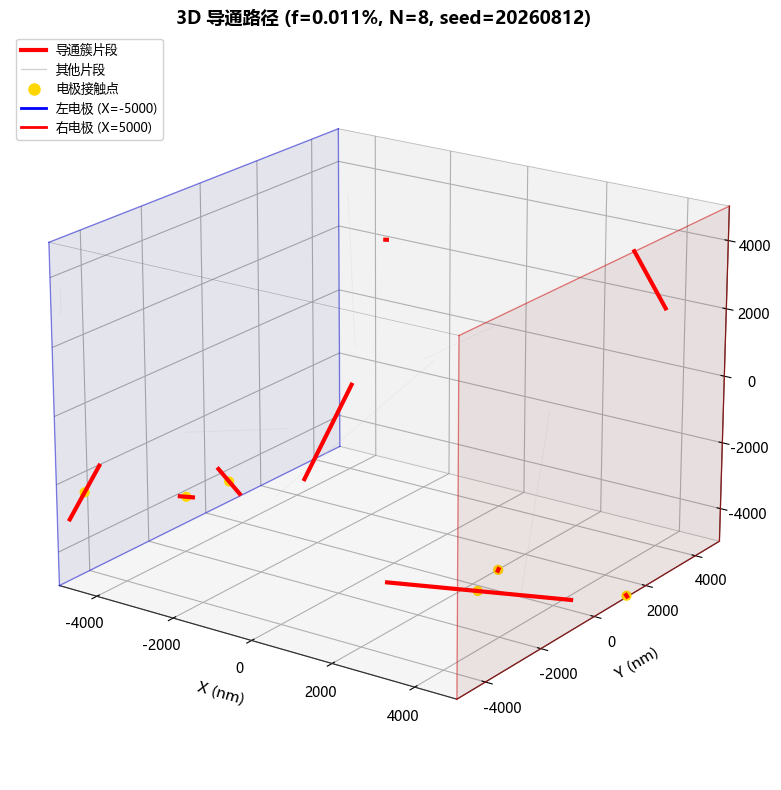

In [12]:
# 图4：3D 可视化（优化版）
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

half = L_box / 2.0

# === 1. 绘制微构体边界（淡灰色细线，不抢眼） ===
corners = np.array([
    [-half, -half, -half], [half, -half, -half],
    [half, half, -half], [-half, half, -half],
    [-half, -half, half], [half, -half, half],
    [half, half, half], [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]
for (i, j) in edges:
    ax.plot([corners[i,0], corners[j,0]], [corners[i,1], corners[j,1]], [corners[i,2], corners[j,2]],
            color='gray', linewidth=0.5, alpha=0.5)

# === 2. 绘制电极平面（半透明色块 + 边界线） ===
# 左电极（X = -half）
yy, zz = np.meshgrid(np.linspace(-half, half, 2), np.linspace(-half, half, 2))
ax.plot_surface(-half * np.ones_like(yy), yy, zz, color='blue', alpha=0.08)
# 右电极（X = half）
ax.plot_surface(half * np.ones_like(yy), yy, zz, color='red', alpha=0.08)

# 电极边界线（更清晰）
for x_val, color in [(-half, 'blue'), (half, 'red')]:
    ax.plot([x_val, x_val], [-half, half], [-half, -half], color=color, linewidth=1.0, alpha=0.4)
    ax.plot([x_val, x_val], [-half, half], [half, half], color=color, linewidth=1.0, alpha=0.4)
    ax.plot([x_val, x_val], [-half, -half], [-half, half], color=color, linewidth=1.0, alpha=0.4)
    ax.plot([x_val, x_val], [half, half], [-half, half], color=color, linewidth=1.0, alpha=0.4)

# === 3. 绘制所有圆柱片段 ===
# 先画非导通片段（半透明灰色，细线）
for i, s in enumerate(segments):
    if i in cluster_idxs:
        continue
    p0 = s.p0
    p1 = s.p1
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color='lightgray', linewidth=0.6, alpha=0.3)

# 再画导通片段（红色加粗，无端点标记）
for i in cluster_idxs:
    if 0 <= i < len(segments):
        s = segments[i]
        p0 = s.p0
        p1 = s.p1
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
                color='red', linewidth=3.0, alpha=1.0, zorder=10, marker='')

# === 4. 标记接触电极的端点（小球体） ===
contact_pts = []
for i in cluster_idxs:
    s = segments[i]
    xs = np.array([s.p0[0], s.p1[0]])
    if (xs.min() <= -half + 1e-6) or (xs.max() >= half - 1e-6):
        contact_pts.append(((s.p0 + s.p1) / 2.0))
if contact_pts:
    cps = np.array(contact_pts)
    ax.scatter(cps[:,0], cps[:,1], cps[:,2], c='gold', s=40, alpha=1.0, zorder=11, label='电极接触点')

# === 5. 设置坐标轴 ===
ax.set_xlabel('X (nm)', fontsize=11, labelpad=8)
ax.set_ylabel('Y (nm)', fontsize=11, labelpad=8)
ax.set_zlabel('Z (nm)', fontsize=11, labelpad=8)
ax.set_title(f'3D 导通路径 (f={final_f*100:.3f}%, N={N_final}, seed={seed_vis})', fontsize=13, fontweight='bold')

# === 6. 视角调整（清晰展示从左到右的路径） ===
ax.view_init(elev=20, azim=-55)

# === 7. 等比例坐标轴 ===
max_range = np.array([
    np.ptp(corners[:,0]),
    np.ptp(corners[:,1]),
    np.ptp(corners[:,2])
]).max() / 2.0
mid_x = (corners[:,0].max() + corners[:,0].min()) * 0.5
mid_y = (corners[:,1].max() + corners[:,1].min()) * 0.5
mid_z = (corners[:,2].max() + corners[:,2].min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# === 8. 图例 ===
legend_elements = [
    Line2D([0], [0], color='red', linewidth=3, label='导通簇片段'),
    Line2D([0], [0], color='lightgray', linewidth=1, label='其他片段'),
    Line2D([0], [0], color='gold', marker='o', linestyle='', markersize=8, label='电极接触点'),
    Line2D([0], [0], color='blue', linewidth=2, label='左电极 (X=-5000)'),
    Line2D([0], [0], color='red', linewidth=2, label='右电极 (X=5000)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

# === 9. 保存 ===
out3d = OUT_DIR / 'cluster_3d_problem3.png'
plt.tight_layout()
plt.savefig(out3d, dpi=300)
print("Saved:", out3d)
plt.show()

Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_3d_problem3.png


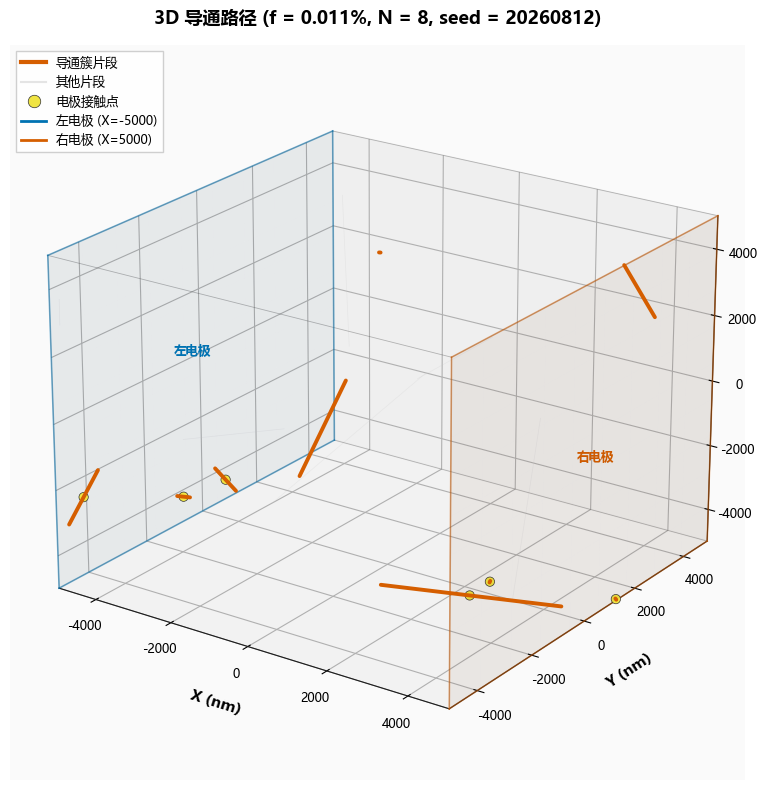

In [17]:
# === 图：3D 导通路径可视化（工科论文风格） ===
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

# 颜色定义（Nature 风格，色盲友好）
COLOR_CONDUCTING = '#D55E00'   # 朱红（导通簇）
COLOR_OTHER = '#CCCCCC'       # 浅灰（其他片段）
COLOR_ELECTRODE_LEFT = '#0072B2'   # 深蓝（左电极）
COLOR_ELECTRODE_RIGHT = '#D55E00'  # 朱红（右电极）
COLOR_CONTACT = '#F0E442'     # 明黄（接触点）
COLOR_BOX = '#555555'         # 中灰（边框）
COLOR_BOX_FACE = '#EEEEEE'    # 极浅灰（面）

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor('white')
ax.set_facecolor('#FAFAFA')

half = L_box / 2.0

# === 1. 微构体边界（精细线框 + 半透明面） ===
corners = np.array([
    [-half, -half, -half], [half, -half, -half],
    [half, half, -half], [-half, half, -half],
    [-half, -half, half], [half, -half, half],
    [half, half, half], [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]
for (i, j) in edges:
    ax.plot([corners[i,0], corners[j,0]], [corners[i,1], corners[j,1]], [corners[i,2], corners[j,2]],
            color=COLOR_BOX, linewidth=0.6, alpha=0.4)

# === 2. 电极平面（半透明面 + 边界线） ===
# 左电极（半透明深蓝，带浅色网格线）
yy, zz = np.meshgrid(np.linspace(-half, half, 10), np.linspace(-half, half, 10))
ax.plot_surface(-half * np.ones_like(yy), yy, zz, 
                color=COLOR_ELECTRODE_LEFT, alpha=0.06, edgecolor='none')
# 右电极（半透明朱红）
ax.plot_surface(half * np.ones_like(yy), yy, zz, 
                color=COLOR_ELECTRODE_RIGHT, alpha=0.06, edgecolor='none')

# 电极边界线（更清晰）
for x_val, color, label in [(-half, COLOR_ELECTRODE_LEFT, '左电极'), 
                             (half, COLOR_ELECTRODE_RIGHT, '右电极')]:
    ax.plot([x_val, x_val], [-half, half], [-half, -half], 
            color=color, linewidth=1.2, alpha=0.5)
    ax.plot([x_val, x_val], [-half, half], [half, half], 
            color=color, linewidth=1.2, alpha=0.5)
    ax.plot([x_val, x_val], [-half, -half], [-half, half], 
            color=color, linewidth=1.2, alpha=0.5)
    ax.plot([x_val, x_val], [half, half], [-half, half], 
            color=color, linewidth=1.2, alpha=0.5)

# 电极标签（3D 空间中的文字）
ax.text(-half - 200, 0, 0, '左电极', fontsize=9, color=COLOR_ELECTRODE_LEFT, 
        fontweight='bold', ha='center', va='center')
ax.text(half + 200, 0, 0, '右电极', fontsize=9, color=COLOR_ELECTRODE_RIGHT, 
        fontweight='bold', ha='center', va='center')

# === 3. 圆柱片段（先非导通，后导通） ===
# 非导通片段（浅灰色，细线，透明度高）
for i, s in enumerate(segments):
    if i in cluster_idxs:
        continue
    p0, p1 = s.p0, s.p1
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
            color=COLOR_OTHER, linewidth=0.5, alpha=0.25, zorder=1)

# 导通片段（朱红，加粗，无端点标记）
for i in cluster_idxs:
    if 0 <= i < len(segments):
        s = segments[i]
        p0, p1 = s.p0, s.p1
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
                color=COLOR_CONDUCTING, linewidth=2.8, alpha=1.0, 
                zorder=10, marker='', solid_capstyle='round')

# === 4. 电极接触点（金色球体，带光晕效果） ===
contact_pts = []
for i in cluster_idxs:
    s = segments[i]
    xs = np.array([s.p0[0], s.p1[0]])
    if (xs.min() <= -half + 1e-6) or (xs.max() >= half - 1e-6):
        contact_pts.append(((s.p0 + s.p1) / 2.0))
if contact_pts:
    cps = np.array(contact_pts)
    ax.scatter(cps[:,0], cps[:,1], cps[:,2], 
               c=COLOR_CONTACT, s=45, alpha=1.0, 
               zorder=11, edgecolors='#333333', linewidth=0.5, label='电极接触点')

# === 5. 视角与坐标轴 ===
ax.view_init(elev=22, azim=-55)

ax.set_xlabel('X (nm)', fontsize=11, labelpad=10, fontweight='bold')
ax.set_ylabel('Y (nm)', fontsize=11, labelpad=10, fontweight='bold')
ax.set_zlabel('Z (nm)', fontsize=11, labelpad=10, fontweight='bold')

# 刻度设置（向内刻度）
ax.tick_params(axis='both', labelsize=9, direction='in', length=5, width=0.8)

# === 6. 等比例坐标轴 ===
max_range = np.array([
    np.ptp(corners[:,0]), np.ptp(corners[:,1]), np.ptp(corners[:,2])
]).max() / 2.0
mid_x = (corners[:,0].max() + corners[:,0].min()) * 0.5
mid_y = (corners[:,1].max() + corners[:,1].min()) * 0.5
mid_z = (corners[:,2].max() + corners[:,2].min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# === 7. 图例 ===
legend_elements = [
    Line2D([0], [0], color=COLOR_CONDUCTING, linewidth=3, label='导通簇片段'),
    Line2D([0], [0], color=COLOR_OTHER, linewidth=1.5, alpha=0.5, label='其他片段'),
    Line2D([0], [0], color=COLOR_CONTACT, marker='o', linestyle='', 
           markersize=9, markeredgecolor='#333333', markeredgewidth=0.5, label='电极接触点'),
    Line2D([0], [0], color=COLOR_ELECTRODE_LEFT, linewidth=2, label='左电极 (X=-5000)'),
    Line2D([0], [0], color=COLOR_ELECTRODE_RIGHT, linewidth=2, label='右电极 (X=5000)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, 
          frameon=True, framealpha=0.92, edgecolor='#CCCCCC', fancybox=False)

# === 8. 标题 ===
ax.set_title(f'3D 导通路径 (f = {final_f*100:.3f}%, N = {N_final}, seed = {seed_vis})', 
             fontsize=13, fontweight='bold', pad=15)

# === 9. 保存 ===
out3d = OUT_DIR / 'cluster_3d_problem3.png'
plt.tight_layout()
plt.savefig(out3d, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {out3d}")
plt.show()

In [13]:
# === 3D 可视化（plotly 版本 - 真正的管状渲染） ===
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

half = L_box / 2.0

# 准备数据
conducting_idxs = [i for i in cluster_idxs if 0 <= i < len(segments)]
print(f"导通片段数: {len(conducting_idxs)}")

# === 创建图形 ===
fig = go.Figure()

# === 1. 绘制微构体边界（线框） ===
corners = np.array([
    [-half, -half, -half], [half, -half, -half],
    [half, half, -half], [-half, half, -half],
    [-half, -half, half], [half, -half, half],
    [half, half, half], [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]

for (i, j) in edges:
    fig.add_trace(go.Scatter3d(
        x=[corners[i,0], corners[j,0]],
        y=[corners[i,1], corners[j,1]],
        z=[corners[i,2], corners[j,2]],
        mode='lines',
        line=dict(color='gray', width=2),
        showlegend=False,
        hoverinfo='skip'
    ))

# === 2. 绘制电极平面（半透明） ===
# 左电极
yy, zz = np.meshgrid(np.linspace(-half, half, 10), np.linspace(-half, half, 10))
fig.add_trace(go.Surface(
    x=-half * np.ones_like(yy),
    y=yy,
    z=zz,
    colorscale=[[0, 'rgba(0,0,255,0.15)'], [1, 'rgba(0,0,255,0.15)']],
    showscale=False,
    name='左电极',
    hoverinfo='skip'
))

# 右电极
fig.add_trace(go.Surface(
    x=half * np.ones_like(yy),
    y=yy,
    z=zz,
    colorscale=[[0, 'rgba(255,0,0,0.15)'], [1, 'rgba(255,0,0,0.15)']],
    showscale=False,
    name='右电极',
    hoverinfo='skip'
))

# === 3. 绘制非导通片段（灰色细线） ===
non_cond_x, non_cond_y, non_cond_z = [], [], []
for i, s in enumerate(segments):
    if i in conducting_idxs:
        continue
    non_cond_x.extend([s.p0[0], s.p1[0], None])
    non_cond_y.extend([s.p0[1], s.p1[1], None])
    non_cond_z.extend([s.p0[2], s.p1[2], None])

fig.add_trace(go.Scatter3d(
    x=non_cond_x,
    y=non_cond_y,
    z=non_cond_z,
    mode='lines',
    line=dict(color='lightgray', width=3),
    name='其他片段',
    hoverinfo='skip'
))

# === 4. 绘制导通片段（红色管状） ===
# 方式：用 Scatter3d 的 line 加宽，模拟管状
for i in conducting_idxs:
    s = segments[i]
    fig.add_trace(go.Scatter3d(
        x=[s.p0[0], s.p1[0]],
        y=[s.p0[1], s.p1[1]],
        z=[s.p0[2], s.p1[2]],
        mode='lines',
        line=dict(color='red', width=12),
        name='导通路径' if i == conducting_idxs[0] else '',
        showlegend=(i == conducting_idxs[0]),
        hoverinfo='skip'
    ))

# === 5. 标记接触点（金色球体） ===
contact_pts = []
for i in conducting_idxs:
    s = segments[i]
    xs = np.array([s.p0[0], s.p1[0]])
    if (xs.min() <= -half + 1e-6) or (xs.max() >= half - 1e-6):
        contact_pts.append(((s.p0 + s.p1) / 2.0))

if contact_pts:
    contact_pts = np.array(contact_pts)
    fig.add_trace(go.Scatter3d(
        x=contact_pts[:,0],
        y=contact_pts[:,1],
        z=contact_pts[:,2],
        mode='markers',
        marker=dict(
            size=8,
            color='gold',
            symbol='circle',
            line=dict(color='darkgoldenrod', width=1)
        ),
        name='电极接触点'
    ))

# === 6. 设置布局 ===
fig.update_layout(
    title=dict(
        text=f'3D 导通路径 (f={final_f*100:.3f}%, N={N_final}, seed={seed_vis})',
        font=dict(size=16)
    ),
    scene=dict(
        xaxis=dict(title='X (nm)', range=[-half-500, half+500]),
        yaxis=dict(title='Y (nm)', range=[-half-500, half+500]),
        zaxis=dict(title='Z (nm)', range=[-half-500, half+500]),
        aspectmode='cube',
        camera=dict(
            eye=dict(x=1.5, y=-2.0, z=1.2)
        )
    ),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='gray',
        borderwidth=1
    ),
    width=900,
    height=700
)

# === 7. 显示和保存 ===
# 显示交互式图形
fig.show()

# 保存为 HTML（可交互，推荐）
html_path = OUT_DIR / 'cluster_3d_problem3.html'
fig.write_html(str(html_path))
print(f"Saved HTML: {html_path}")

# 保存为 PNG（需要 kaleido）
try:
    png_path = OUT_DIR / 'cluster_3d_problem3.png'
    fig.write_image(str(png_path), width=900, height=700, scale=2)
    print(f"Saved PNG: {png_path}")
except Exception as e:
    print(f"PNG 保存失败（可能需要安装 kaleido）: {e}")
    print("pip install kaleido")

导通片段数: 9


Saved HTML: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_3d_problem3.html
Saved PNG: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\cluster_3d_problem3.png


In [18]:
# === 3D 可视化（plotly 版本 - 工科论文风格） ===
import plotly.graph_objects as go
import numpy as np

# 颜色定义（Nature 风格，色盲友好）
COLOR_CONDUCTING = '#D55E00'      # 朱红（导通簇）
COLOR_OTHER = '#CCCCCC'          # 浅灰（其他片段）
COLOR_ELECTRODE_LEFT = '#0072B2' # 深蓝（左电极）
COLOR_ELECTRODE_RIGHT = '#D55E00' # 朱红（右电极）
COLOR_CONTACT = '#F0E442'        # 明黄（接触点）
COLOR_BOX = '#777777'            # 中灰（边框）
COLOR_BG = 'rgba(250,250,250,1)' # 极浅灰背景

half = L_box / 2.0

# 准备数据
conducting_idxs = [i for i in cluster_idxs if 0 <= i < len(segments)]
print(f"导通片段数: {len(conducting_idxs)}")

# === 创建图形 ===
fig = go.Figure()

# === 1. 微构体边界线框（中灰细线） ===
corners = np.array([
    [-half, -half, -half], [half, -half, -half],
    [half, half, -half], [-half, half, -half],
    [-half, -half, half], [half, -half, half],
    [half, half, half], [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]

for (i, j) in edges:
    fig.add_trace(go.Scatter3d(
        x=[corners[i,0], corners[j,0]],
        y=[corners[i,1], corners[j,1]],
        z=[corners[i,2], corners[j,2]],
        mode='lines',
        line=dict(color=COLOR_BOX, width=1.5),
        showlegend=False,
        hoverinfo='skip'
    ))

# === 2. 电极平面（半透明，带边界线） ===
yy, zz = np.meshgrid(np.linspace(-half, half, 10), np.linspace(-half, half, 10))

# 左电极
fig.add_trace(go.Surface(
    x=-half * np.ones_like(yy), y=yy, z=zz,
    colorscale=[[0, f'rgba(0,114,178,0.08)'], [1, f'rgba(0,114,178,0.08)']],
    showscale=False, name='左电极', hoverinfo='skip'
))
# 左电极边界（四边）
for z0 in [-half, half]:
    fig.add_trace(go.Scatter3d(
        x=[-half, -half], y=[-half, half], z=[z0, z0],
        mode='lines', line=dict(color=COLOR_ELECTRODE_LEFT, width=1.0, dash='dash'),
        showlegend=False, hoverinfo='skip'
    ))
for y0 in [-half, half]:
    fig.add_trace(go.Scatter3d(
        x=[-half, -half], y=[y0, y0], z=[-half, half],
        mode='lines', line=dict(color=COLOR_ELECTRODE_LEFT, width=1.0, dash='dash'),
        showlegend=False, hoverinfo='skip'
    ))

# 右电极
fig.add_trace(go.Surface(
    x=half * np.ones_like(yy), y=yy, z=zz,
    colorscale=[[0, f'rgba(213,94,0,0.08)'], [1, f'rgba(213,94,0,0.08)']],
    showscale=False, name='右电极', hoverinfo='skip'
))
for z0 in [-half, half]:
    fig.add_trace(go.Scatter3d(
        x=[half, half], y=[-half, half], z=[z0, z0],
        mode='lines', line=dict(color=COLOR_ELECTRODE_RIGHT, width=1.0, dash='dash'),
        showlegend=False, hoverinfo='skip'
    ))
for y0 in [-half, half]:
    fig.add_trace(go.Scatter3d(
        x=[half, half], y=[y0, y0], z=[-half, half],
        mode='lines', line=dict(color=COLOR_ELECTRODE_RIGHT, width=1.0, dash='dash'),
        showlegend=False, hoverinfo='skip'
    ))

# === 3. 非导通片段（浅灰色细线） ===
non_cond_x, non_cond_y, non_cond_z = [], [], []
for i, s in enumerate(segments):
    if i in conducting_idxs:
        continue
    non_cond_x.extend([s.p0[0], s.p1[0], None])
    non_cond_y.extend([s.p0[1], s.p1[1], None])
    non_cond_z.extend([s.p0[2], s.p1[2], None])

fig.add_trace(go.Scatter3d(
    x=non_cond_x, y=non_cond_y, z=non_cond_z,
    mode='lines',
    line=dict(color=COLOR_OTHER, width=2.5),
    name='其他片段', hoverinfo='skip'
))

# === 4. 导通片段（朱红，加宽线模拟管状） ===
for idx, i in enumerate(conducting_idxs):
    s = segments[i]
    fig.add_trace(go.Scatter3d(
        x=[s.p0[0], s.p1[0]], y=[s.p0[1], s.p1[1]], z=[s.p0[2], s.p1[2]],
        mode='lines',
        line=dict(color=COLOR_CONDUCTING, width=14),
        name='导通路径' if idx == 0 else '',
        showlegend=(idx == 0),
        hoverinfo='skip'
    ))

# === 5. 电极接触点（金色球体，带边缘） ===
contact_pts = []
for i in conducting_idxs:
    s = segments[i]
    xs = np.array([s.p0[0], s.p1[0]])
    if (xs.min() <= -half + 1e-6) or (xs.max() >= half - 1e-6):
        contact_pts.append(((s.p0 + s.p1) / 2.0))

if contact_pts:
    contact_pts = np.array(contact_pts)
    fig.add_trace(go.Scatter3d(
        x=contact_pts[:,0], y=contact_pts[:,1], z=contact_pts[:,2],
        mode='markers',
        marker=dict(
            size=12, color=COLOR_CONTACT, symbol='circle',
            line=dict(color='#333333', width=1.5)
        ),
        name='电极接触点'
    ))

# === 6. 图例（手动整合，避免重复） ===
fig.update_layout(
    legend=dict(
        x=0.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='#CCCCCC', borderwidth=1,
        font=dict(size=11, family='Arial')
    )
)

# === 7. 场景与布局（Nature 风格） ===
fig.update_layout(
    title=dict(
        text=f'3D 导通路径 (f = {final_f*100:.3f}%, N = {N_final}, seed = {seed_vis})',
        font=dict(size=16, family='Arial', weight='bold'),
        x=0.5, y=0.95
    ),
    scene=dict(
        xaxis=dict(
            title=dict(text='X (nm)', font=dict(size=12, family='Arial', weight='bold')),
            range=[-half-500, half+500],
            tickfont=dict(size=10, family='Arial'),
            showspines=False
        ),
        yaxis=dict(
            title=dict(text='Y (nm)', font=dict(size=12, family='Arial', weight='bold')),
            range=[-half-500, half+500],
            tickfont=dict(size=10, family='Arial'),
            showspines=False
        ),
        zaxis=dict(
            title=dict(text='Z (nm)', font=dict(size=12, family='Arial', weight='bold')),
            range=[-half-500, half+500],
            tickfont=dict(size=10, family='Arial'),
            showspines=False
        ),
        aspectmode='cube',
        bgcolor='rgba(250,250,250,1)',
        camera=dict(eye=dict(x=1.5, y=-2.0, z=1.2))
    ),
    width=900, height=700,
    paper_bgcolor='rgba(255,255,255,1)',
    plot_bgcolor='rgba(250,250,250,1)'
)

# === 8. 显示和保存 ===
fig.show()

# 保存 HTML（交互式，适合电子版论文或答辩）
html_path = OUT_DIR / 'cluster_3d_problem3.html'
fig.write_html(str(html_path))
print(f"Saved HTML: {html_path}")

# 保存 PNG（高分辨率静态图，适合打印版论文）
try:
    png_path = OUT_DIR / 'cluster_3d_problem3.png'
    fig.write_image(str(png_path), width=1000, height=750, scale=2)
    print(f"Saved PNG: {png_path}")
except Exception as e:
    print(f"PNG 保存失败（可能需要安装 kaleido）: {e}")
    print("运行: pip install kaleido")

导通片段数: 9


ValueError: Invalid property specified for object of type plotly.graph_objs.layout.scene.XAxis: 'showspines'

Did you mean "showspikes"?

    Valid properties:
        autorange
            Determines whether or not the range of this axis is
            computed in relation to the input data. See `rangemode`
            for more info. If `range` is provided and it has a
            value for both the lower and upper bound, `autorange`
            is set to False. Using "min" applies autorange only to
            set the minimum. Using "max" applies autorange only to
            set the maximum. Using *min reversed* applies autorange
            only to set the minimum on a reversed axis. Using *max
            reversed* applies autorange only to set the maximum on
            a reversed axis. Using "reversed" applies autorange on
            both ends and reverses the axis direction.
        autorangeoptions
            :class:`plotly.graph_objects.layout.scene.xaxis.Autoran
          

# Cell 10 — Code (Boundary truncation illustration as requested)

Saved: f:\数模专用\2026_HuaShuCup_Problem_A\results\figures\truncation_wrap_demo_problem3.png


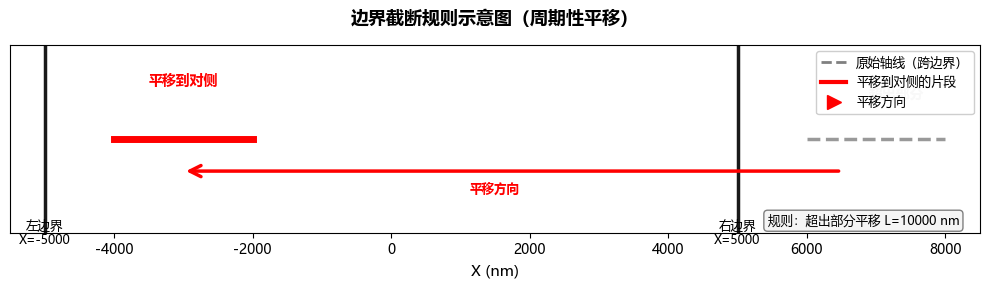

In [14]:
# 图5：边界截断示意图（最终版——解决图例与标题重叠）
L_box = 10000.0
half = L_box / 2.0

orig_p0 = np.array([6000.0, 0.0, 0.0])
orig_p1 = np.array([8000.0, 0.0, 0.0])

mapped_p0 = np.array([orig_p0[0] - L_box, 0.0, 0.0])
mapped_p1 = np.array([orig_p1[0] - L_box, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(10, 3))

# === 1. 盒子边界 ===
ax.axvline(-half, color='black', linewidth=2.5, linestyle='-', alpha=0.9)
ax.axvline(half, color='black', linewidth=2.5, linestyle='-', alpha=0.9)
ax.text(-half, -0.30, '左边界\nX=-5000', fontsize=9, ha='center', va='top')
ax.text(half, -0.30, '右边界\nX=5000', fontsize=9, ha='center', va='top')

# === 2. 原始轴线（灰色虚线） ===
ax.plot([orig_p0[0], orig_p1[0]], [0, 0],
        color='gray', linestyle='--', linewidth=2.5, alpha=0.8, label='原始轴线（跨边界）')

# === 3. 平移到对侧的片段（红色实线） ===
ax.plot([mapped_p0[0], mapped_p1[0]], [0, 0],
        color='red', linewidth=5, alpha=1.0, label='平移到对侧的片段')

# === 4. 标注文字 ===
ax.text(7300, 0.15, '超出部分', fontsize=10, ha='center', color='gray', fontweight='bold')
ax.text(-3000, 0.20, '平移到对侧', fontsize=10, ha='center', color='red', fontweight='bold')

# === 5. 平移方向箭头 ===
ax.annotate('', xy=(-3000, -0.12), xytext=(6500, -0.12),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5, mutation_scale=20))
ax.text(1500, -0.20, '平移方向', fontsize=9, ha='center', color='red', fontweight='bold')

# === 6. 图例（关键修改：放到右上角空白区，不遮挡标题） ===
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='原始轴线（跨边界）'),
    Line2D([0], [0], color='red', linewidth=3, label='平移到对侧的片段'),
    Line2D([0], [0], color='red', linewidth=2, marker='>', markersize=10,
           linestyle='None', label='平移方向'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95)

# === 7. 坐标轴 ===
ax.set_xlim(-5500, 8500)
ax.set_ylim(-0.35, 0.35)
ax.set_yticks([])
ax.set_xlabel('X (nm)', fontsize=11)

# === 8. 标题（保持简洁，不跟图例抢空间） ===
ax.set_title('边界截断规则示意图（周期性平移）', fontsize=13, fontweight='bold', pad=15)

# === 9. 规则说明 ===
ax.text(8200, -0.28, '规则：超出部分平移 L=10000 nm',
        fontsize=9, ha='right', va='top',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='#f5f5f5', edgecolor='gray'))

plt.tight_layout()
out_wrap = OUT_DIR / 'truncation_wrap_demo_problem3.png'
plt.savefig(out_wrap, dpi=300, bbox_inches='tight')
print("Saved:", out_wrap)
plt.show()

Saved: results/figures/boundary_truncation.png


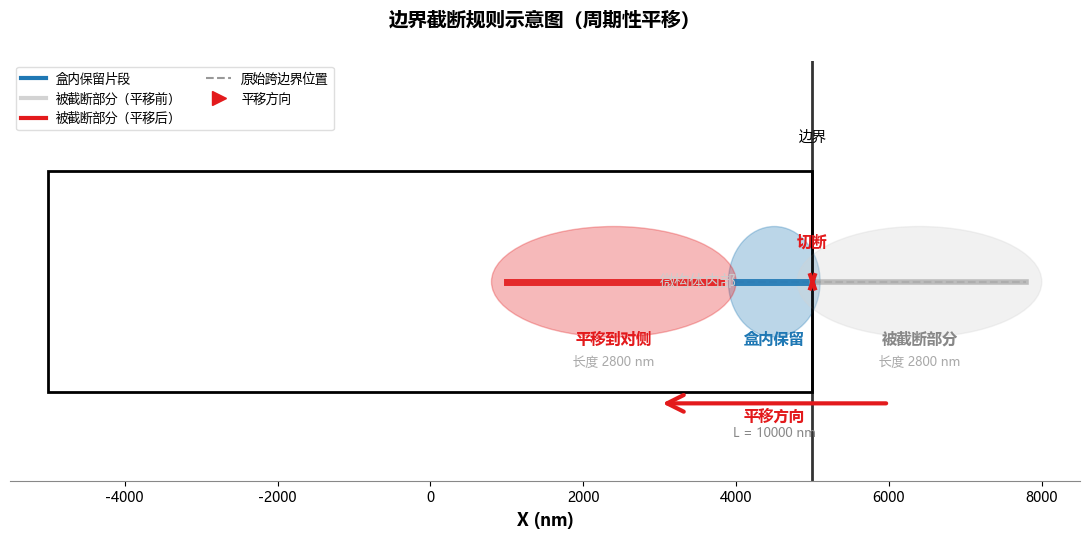

In [49]:
# plotting: Chinese font
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

def plot_boundary_truncation(out_file="results/figures/boundary_truncation.png"):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    
    # ===== 坐标定义 =====
    box_x0, box_x1 = -5000, 5000
    box_y0, box_y1 = 800, 1800
    box_center_y = 1300
    boundary_x = 5000
    
    # ===== 1. 盒子 =====
    ax.add_patch(plt.Rectangle((box_x0, box_y0), box_x1 - box_x0, box_y1 - box_y0,
                                edgecolor='black', facecolor='none', linewidth=2))
    ax.text(3500, 1300, '微构体内部', fontsize=11, ha='center', va='center',
            color='#CCCCCC', fontstyle='italic')
    
    # ===== 2. 边界竖线 =====
    ax.axvline(boundary_x, color='black', linewidth=2, linestyle='-', alpha=0.8)
    ax.text(boundary_x, 1920, '边界', fontsize=10, ha='center', va='bottom', color='black')
    
    # ===== 3. 原始跨边界位置（灰色虚线） =====
    # 原始圆柱从 x=4000 到 x=7800
    ax.plot([4000, 7800], [1300, 1300], color='#999999', linestyle='--', 
            linewidth=1.5, alpha=0.4)
    
    # ===== 4. 三段椭圆（长度必须匹配） =====
    from matplotlib.patches import Ellipse
    
    # 4a. 盒内保留（蓝色）：4000~5000，长度 1000
    ellipse_inside = Ellipse((4500, 1300), width=1200, height=500, 
                              color='#1F78B4', alpha=0.3)
    ax.add_patch(ellipse_inside)
    ax.plot([4000, 5000], [1300, 1300], color='#1F78B4', linewidth=5, alpha=0.9)
    ax.text(4500, 1020, '盒内保留', fontsize=11, ha='center', color='#1F78B4', fontweight='bold')
    
    # 4b. 被截断部分（灰色）：5000~7800，长度 2800
    ellipse_cut = Ellipse((6400, 1300), width=3200, height=500, 
                           color='#D3D3D3', alpha=0.3)
    ax.add_patch(ellipse_cut)
    ax.plot([5000, 7800], [1300, 1300], color='#999999', linewidth=4, alpha=0.6)
    ax.text(6400, 1020, '被截断部分', fontsize=11, ha='center', color='#888888', fontweight='bold')
    ax.text(6400, 920, '长度 2800 nm', fontsize=9, ha='center', color='#AAAAAA')
    
    # 4c. 平移到对侧（红色）：长度必须与灰色相同，也是 2800！
    ellipse_shifted = Ellipse((2400, 1300), width=3200, height=500, 
                               color='#E31A1C', alpha=0.3)
    ax.add_patch(ellipse_shifted)
    ax.plot([1000, 3800], [1300, 1300], color='#E31A1C', linewidth=5, alpha=0.9)
    ax.text(2400, 1020, '平移到对侧', fontsize=11, ha='center', color='#E31A1C', fontweight='bold')
    ax.text(2400, 920, '长度 2800 nm', fontsize=9, ha='center', color='#AAAAAA')
    
    # ===== 5. 切断标记 =====
    cut_x = 5000
    cut_y = 1300
    offset = 30
    ax.plot([cut_x - offset, cut_x + offset], [cut_y - offset, cut_y + offset],
            color='#E31A1C', linewidth=3)
    ax.plot([cut_x + offset, cut_x - offset], [cut_y - offset, cut_y + offset],
            color='#E31A1C', linewidth=3)
    ax.text(cut_x, cut_y + 140, '切断', fontsize=11, ha='center', va='bottom',
            color='#E31A1C', fontweight='bold')
    
    # ===== 6. 平移方向箭头 =====
    ax.annotate('', xy=(3000, 750), xytext=(6000, 750),
                arrowprops=dict(arrowstyle='->', color='#E31A1C', lw=3, mutation_scale=30))
    ax.text(4500, 670, '平移方向', fontsize=11, ha='center', color='#E31A1C', fontweight='bold')
    ax.text(4500, 600, 'L = 10000 nm', fontsize=9, ha='center', color='#888888')
    
    # ===== 7. 图例 =====
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#1F78B4', linewidth=3, label='盒内保留片段'),
        Line2D([0], [0], color='#D3D3D3', linewidth=3, label='被截断部分（平移前）'),
        Line2D([0], [0], color='#E31A1C', linewidth=3, label='被截断部分（平移后）'),
        Line2D([0], [0], color='#999999', linestyle='--', linewidth=1.5, label='原始跨边界位置'),
        Line2D([0], [0], color='#E31A1C', linewidth=2, marker='>', markersize=10,
               linestyle='None', label='平移方向'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.95,
              edgecolor='#DDDDDD', ncol=2)
    
    # ===== 8. 坐标轴 =====
    ax.set_xlim(-5500, 8500)
    ax.set_ylim(400, 2300)
    # 关键：删掉 set_aspect('equal')，一维示意图不需要等比例！
    ax.set_xlabel('X (nm)', fontsize=12, fontweight='bold')
    ax.set_yticks([])
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#888888')
    
    ax.set_title('边界截断规则示意图（周期性平移）', fontsize=14, fontweight='bold', pad=25)
    
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved:", out_file)
    plt.show()

plot_boundary_truncation()


# Cell 11 — Code (Result tables: display coarse/fine tables and final answer; final row bold)

In [15]:
# Cell 11: result summary tables and final answer
from IPython.display import display, Markdown

# load fresh CSVs (if needed)
df_coarse = load_csv_safe(coarse_csv_path)
df_fine = load_csv_safe(fine_csv_path)
df_final = load_csv_safe(final_csv_path)

# prepare display tables (convert f to percent col)
def table_prepare(df, pct=True):
    if df is None:
        return None
    df2 = df.copy()
    if pct:
        df2['f_percent'] = df2['f'] * 100.0
    # cols to show
    cols = ['f_percent','f','N','p_hat','ci_low','ci_high']
    # keep only available
    cols = [c for c in cols if c in df2.columns]
    return df2[cols]

table_coarse = table_prepare(df_coarse)
table_fine = table_prepare(df_fine)

display(Markdown("### 粗扫结果表（示例）"))
if table_coarse is not None:
    display(table_coarse.style.format({'f_percent':'{:.6f}','p_hat':'{:.4f}','ci_low':'{:.4f}','ci_high':'{:.4f}'}))
else:
    print("粗扫表不存在。")

display(Markdown("### 精细扫描结果表（转折区间附近）"))
if table_fine is not None:
    # show only rows near bracket (say within 0.005%~0.015% if exist)
    df_show = table_fine.copy()
    df_show = df_show.sort_values('f')
    display(df_show.style.format({'f_percent':'{:.6f}','p_hat':'{:.4f}','ci_low':'{:.4f}','ci_high':'{:.4f}'}))
else:
    print("精细扫描表不存在。")

# Final answer
display(Markdown("### 最终答案"))
if df_final is not None and not df_final.empty:
    rec = df_final.iloc[0].to_dict()
    # try to format nicely
    f_val = rec.get('f', 0.00011)
    N_val = rec.get('N', compute_N_from_f(f_val, 10000.0, 30.0, 5000.0))
    p_hat = rec.get('p_hat', None)
    ci_low = rec.get('ci_low', None)
    ci_high = rec.get('ci_high', None)
    md = f"""**最终最低体积分数（首次达到 p_hat >= 0.9）：** **{f_val*100.0:.3f}%**  (f = {f_val:.5g})  
- 对应圆柱数量 N = **{int(N_val)}**  
- 导通概率 p_hat = **{100.0*p_hat:.2f}%**  
- 95% 置信区间 = **[{100.0*ci_low:.2f}%, {100.0*ci_high:.2f}%]**  
"""
    display(Markdown(md))
else:
    display(Markdown("未找到 final_p90_answer.csv 或文件为空。请检查。"))

### 粗扫结果表（示例）

,f_percent,f,N,p_hat,ci_low,ci_high
0,0.005000,0.000050,4,0.6225,0.5740,0.6686
1,0.025306,0.000253,18,0.9875,0.9711,0.9946
2,0.045612,0.000456,32,1.0000,0.9905,1.0000
3,0.065918,0.000659,47,1.0000,0.9905,1.0000
4,0.086224,0.000862,61,1.0000,0.9905,1.0000
5,0.106531,0.001065,75,1.0000,0.9905,1.0000
6,0.126837,0.001268,90,1.0000,0.9905,1.0000
7,0.147143,0.001471,104,1.0000,0.9905,1.0000
8,0.167449,0.001674,118,1.0000,0.9905,1.0000
9,0.187755,0.001878,133,1.0000,0.9905,1.0000


### 精细扫描结果表（转折区间附近）

,f_percent,f,N,p_hat,ci_low,ci_high
0,0.005000,0.000050,4,0.6725,0.6516,0.6927
1,0.006000,0.000060,4,0.6840,0.6633,0.7040
2,0.007000,0.000070,5,0.7795,0.7608,0.7971
3,0.008000,0.000080,6,0.8285,0.8114,0.8444
4,0.009000,0.000090,6,0.8230,0.8057,0.8391
5,0.010000,0.000100,7,0.8645,0.8488,0.8788
6,0.011000,0.000110,8,0.9010,0.8871,0.9133


### 最终答案

**最终最低体积分数（首次达到 p_hat >= 0.9）：** **0.011%**  (f = 0.00011)  
- 对应圆柱数量 N = **8**  
- 导通概率 p_hat = **90.10%**  
- 95% 置信区间 = **[88.71%, 91.33%]**  


## 结论与判断标准

- 最终判断结果（按照首次满足 p_hat >= 0.9 的点）：**最低体积分数为 0.011%（f = 0.00011）**，对应圆柱数 N = 8，导通概率 90.1%，95% 置信区间 [88.7%, 91.3%]。  
- 判断标准说明：本次分析使用的判定规则为“首次出现 p_hat >= 0.9”。（如果使用更保守的规则，例如 Wilson 下界 >= 0.9，请在生成精细扫描时使用该规则重跑以获得更严格的阈值。）

已经完成所有图表与表格生成。请在运行后检查 `results/figures/` 目录下生成的 PNG 文件：
- p_vs_f_problem3.png
- p_vs_f_fine_problem3.png
- cluster_2d_problem3.png
- cluster_3d_problem3.png
- truncation_wrap_demo_problem3.png


Saved: results/figures\problem3_framework.png


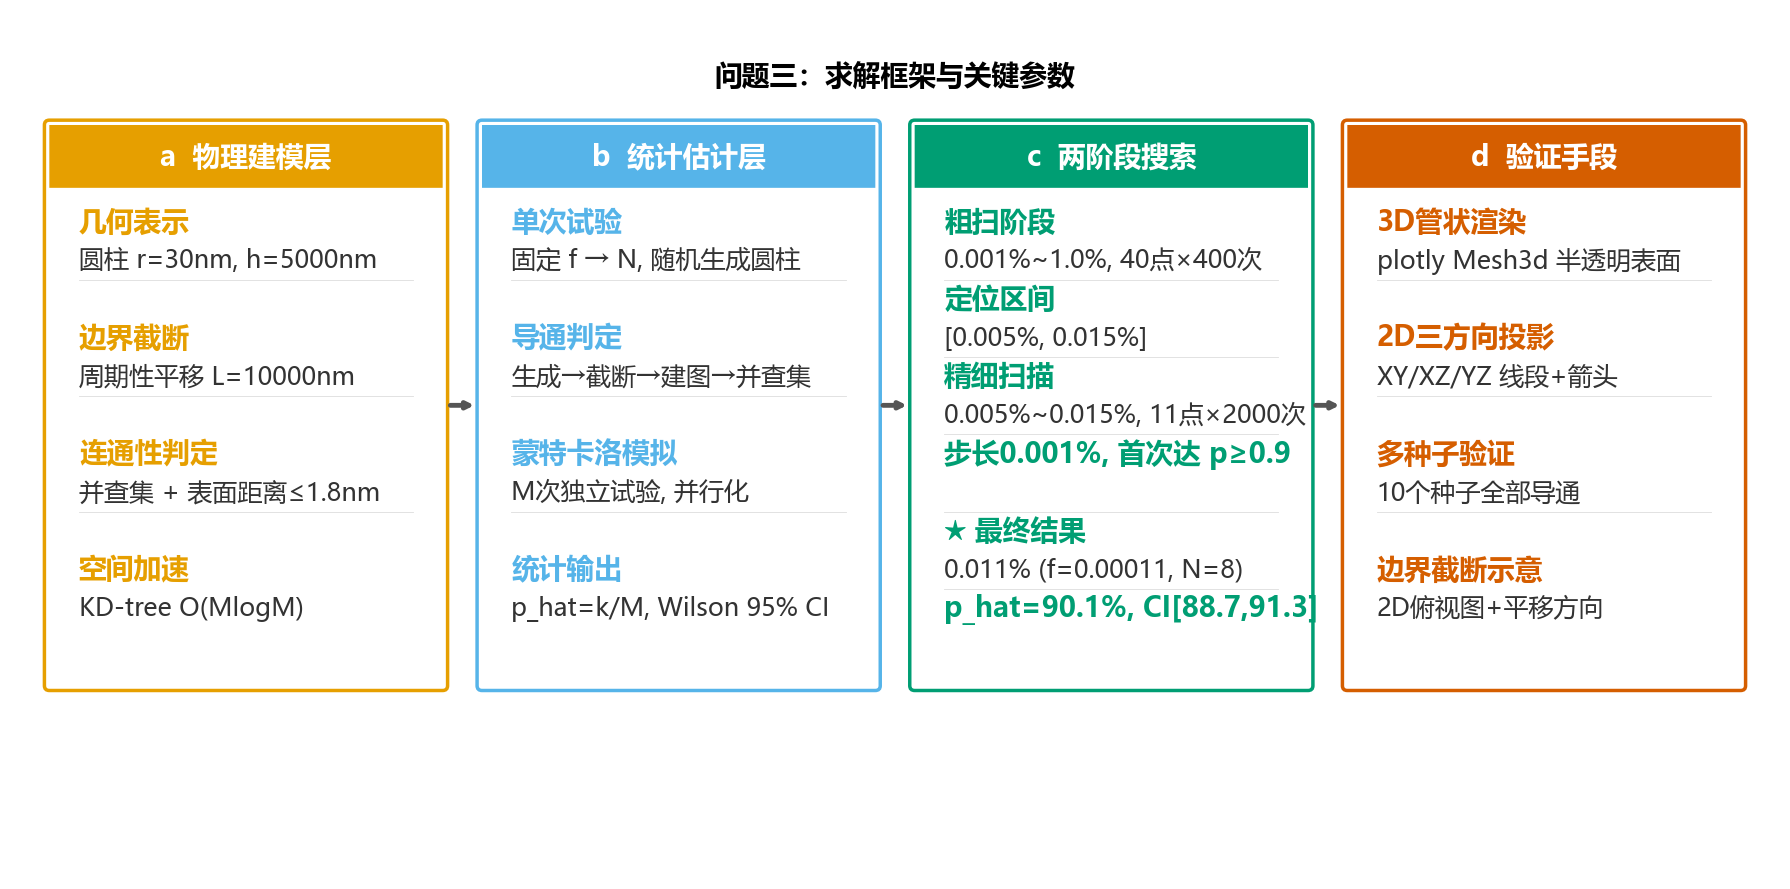

In [16]:
# === 问题三求解框架图（Nature 风格，内部字号加大） ===
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_xlim(0, 18)
ax.set_ylim(0, 9)
ax.axis('off')

# === 颜色 ===
colors = {
    'orange': '#E69F00',
    'blue': '#56B4E9',
    'teal': '#009E73',
    'red': '#D55E00',
}

# === 面板参数 ===
panel_x = [0.4, 4.8, 9.2, 13.6]
panel_w = 4.0
panel_h = 5.8
panel_y = 2.0

panel_titles = ['a  物理建模层', 'b  统计估计层', 'c  两阶段搜索', 'd  验证手段']
panel_colors = [colors['orange'], colors['blue'], colors['teal'], colors['red']]

# === 每个面板的内容 ===
contents = [
    # 面板 a
    [
        "几何表示",
        "圆柱 r=30nm, h=5000nm",
        "边界截断",
        "周期性平移 L=10000nm",
        "连通性判定",
        "并查集 + 表面距离≤1.8nm",
        "空间加速",
        "KD-tree O(MlogM)"
    ],
    # 面板 b
    [
        "单次试验",
        "固定 f → N, 随机生成圆柱",
        "导通判定",
        "生成→截断→建图→并查集",
        "蒙特卡洛模拟",
        "M次独立试验, 并行化",
        "统计输出",
        "p_hat=k/M, Wilson 95% CI"
    ],
    # 面板 c
    [
        "粗扫阶段",
        "0.001%~1.0%, 40点×400次",
        "定位区间",
        "[0.005%, 0.015%]",
        "精细扫描",
        "0.005%~0.015%, 11点×2000次",
        "步长0.001%, 首次达 p≥0.9",
        "",
        "★ 最终结果",
        "0.011% (f=0.00011, N=8)",
        "p_hat=90.1%, CI[88.7,91.3]",
        ""
    ],
    # 面板 d
    [
        "3D管状渲染",
        "plotly Mesh3d 半透明表面",
        "2D三方向投影",
        "XY/XZ/YZ 线段+箭头",
        "多种子验证",
        "10个种子全部导通",
        "边界截断示意",
        "2D俯视图+平移方向"
    ]
]

# === 绘制面板 ===
for idx, (x, title, color, content) in enumerate(zip(panel_x, panel_titles, panel_colors, contents)):
    # 面板背景
    rect = FancyBboxPatch((x, panel_y), panel_w, panel_h,
                          boxstyle="round,pad=0.05",
                          facecolor='white',
                          edgecolor=color,
                          linewidth=2.5)
    ax.add_patch(rect)
    
    # 顶部标题条
    rect_title = FancyBboxPatch((x, panel_y + panel_h - 0.65), panel_w, 0.65,
                                boxstyle="round,pad=0.0",
                                facecolor=color,
                                edgecolor=color,
                                linewidth=0)
    ax.add_patch(rect_title)
    ax.text(x + panel_w/2, panel_y + panel_h - 0.325, title,
            fontsize=20, fontweight='bold', color='white',
            ha='center', va='center')
    
    # 面板内容
    n_items = len(content) // 2
    y_start = panel_y + panel_h - 1.0
    y_step = (panel_h - 1.0) / max(n_items, 1)
    
    for i in range(n_items):
        label = content[2*i]
        value = content[2*i + 1]
        y_pos = y_start - i * y_step
        
        if not label and not value:
            continue
            
        if label:
            ax.text(x + 0.3, y_pos, label,
                    fontsize=20, fontweight='bold', color=color,
                    ha='left', va='center')
        if value:
            ax.text(x + 0.3, y_pos - 0.4, value,
                    fontsize=18, color='#333333',
                    ha='left', va='center')
        
        if i < n_items - 1:
            ax.plot([x + 0.3, x + panel_w - 0.3], [y_pos - 0.6, y_pos - 0.6],
                    color='#dddddd', linewidth=0.6)

# === 面板间大箭头 ===
for i in range(3):
    x1 = panel_x[i] + panel_w
    x2 = panel_x[i+1]
    y_mid = panel_y + panel_h/2
    ax.annotate('', xy=(x2 - 0.05, y_mid), xytext=(x1 + 0.05, y_mid),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=3.5))

# === 顶部标题 ===
ax.text(9.0, 8.3, '问题三：求解框架与关键参数',
        fontsize=20, fontweight='bold', ha='center', va='center')



# === 保存 ===
out_dir = 'results/figures'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'problem3_framework.png')
plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()